# 법률 판례 데이터 EDA 및 시각화


## 0. 라이브러리 설치 및 불러오기

In [1]:
!pip install konlpy
!apt-get install -y default-jdk > /dev/null 2>&1

   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   --------------------- ------------------ 10.5/19.4 MB 56.3 MB/s eta 0:00:01
   ---------------------------------------- 19.4/19.4 MB 52.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 48.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
������ ��θ� ã�� �� �����ϴ�.


In [5]:


import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료!')

라이브러리 로드 완료!


## 1. 데이터 불러오기

In [ ]:
# 파일 경로
train = pd.read_csv('processed_data/train.csv')
val   = pd.read_csv('processed_data/val.csv')
test  = pd.read_csv('processed_data/test.csv')

print(f'학습 데이터: {len(train)}건')
print(f'검증 데이터: {len(val)}건')
print(f'테스트 데이터: {len(test)}건')
print(f'전체: {len(train)+len(val)+len(test)}건')
train.head(3)

FileNotFoundError: [Errno 2] No such file or directory: '/processed_data/train.csv'

## 2. 클래스 분포 확인

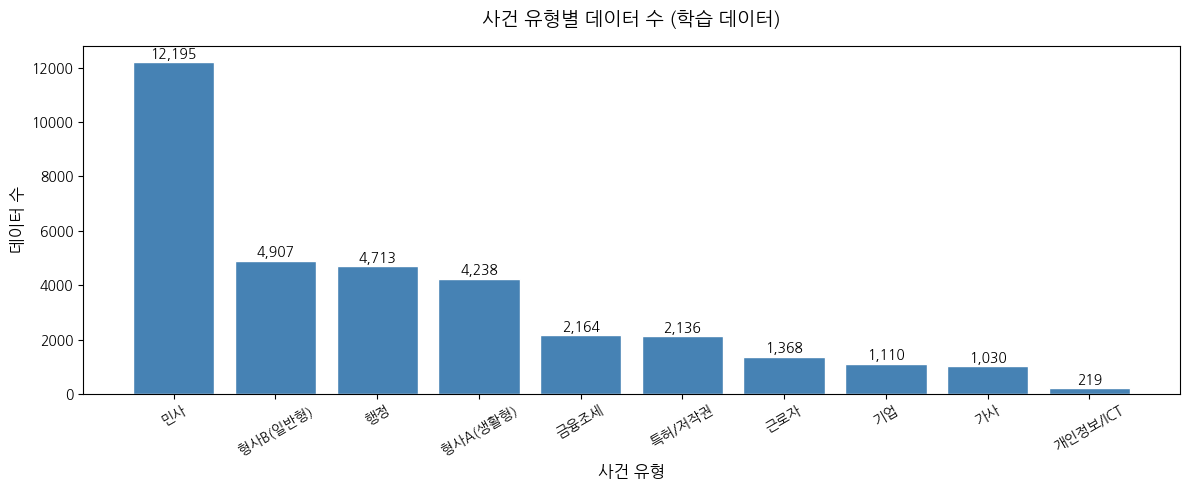


--- 클래스별 비율 ---
class_name
민사          35.8
형사B(일반형)    14.4
행정          13.8
형사A(생활형)    12.4
금융조세         6.3
특허/저작권       6.3
근로자          4.0
기업           3.3
가사           3.0
개인정보/ICT     0.6


In [15]:
class_counts = train['class_name'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='white')

# 막대 위에 숫자 표시
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=10)

ax.set_title('사건 유형별 데이터 수 (학습 데이터)', fontsize=14, pad=15)
ax.set_xlabel('사건 유형', fontsize=12)
ax.set_ylabel('데이터 수', fontsize=12)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print('\n--- 클래스별 비율 ---')
print((class_counts / len(train) * 100).round(1).to_string())

## 3. 텍스트 길이 분포 분석

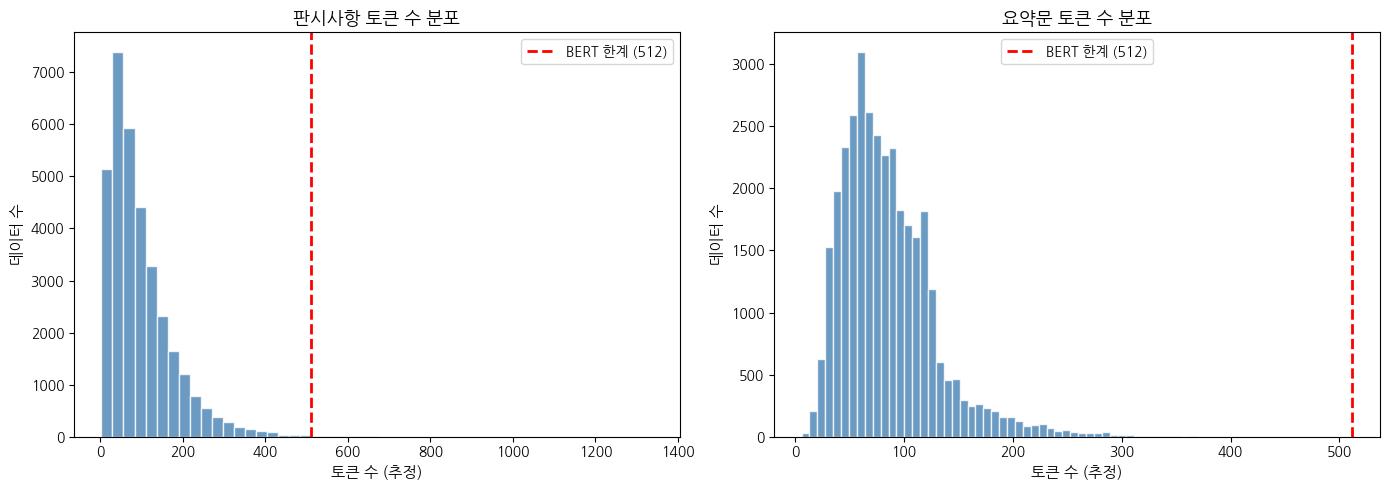

--- 판시사항 ---
count    34080.0
mean        98.0
std         82.0
min          3.0
25%         41.0
50%         77.0
75%        130.0
max       1338.0
Name: jdgmn_token, dtype: float64
512 토큰 초과 비율: 0.3%

--- 요약문 ---
count    34080.0
mean        85.0
std         44.0
min          6.0
25%         54.0
50%         77.0
75%        108.0
max        369.0
Name: summ_pass_token, dtype: float64
512 토큰 초과 비율: 0.0%


In [16]:
# 글자 수 계산
train['jdgmn_len']    = train['jdgmn'].fillna('').apply(len)
train['summ_pass_len'] = train['summ_pass'].fillna('').apply(len)

# 토큰 수 추정 (한국어는 글자 수 / 2 정도가 토큰 수와 비슷)
train['jdgmn_token']    = train['jdgmn_len'] // 2
train['summ_pass_token'] = train['summ_pass_len'] // 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
    ['jdgmn_token', 'summ_pass_token'],
    ['판시사항 토큰 수 분포', '요약문 토큰 수 분포']):

    ax.hist(train[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(512, color='red', linestyle='--', linewidth=2, label='BERT 한계 (512)')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('토큰 수 (추정)', fontsize=11)
    ax.set_ylabel('데이터 수', fontsize=11)
    ax.legend()

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150)
plt.show()

print('--- 판시사항 ---')
print(train['jdgmn_token'].describe().round(0))
over_512 = (train['jdgmn_token'] > 512).sum()
print(f'512 토큰 초과 비율: {over_512/len(train)*100:.1f}%')

print('\n--- 요약문 ---')
print(train['summ_pass_token'].describe().round(0))
over_512_s = (train['summ_pass_token'] > 512).sum()
print(f'512 토큰 초과 비율: {over_512_s/len(train)*100:.1f}%')

## 4. 카테고리별 텍스트 길이 비교

/tmp/ipykernel_3004/4223454038.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=order, patch_artist=True)


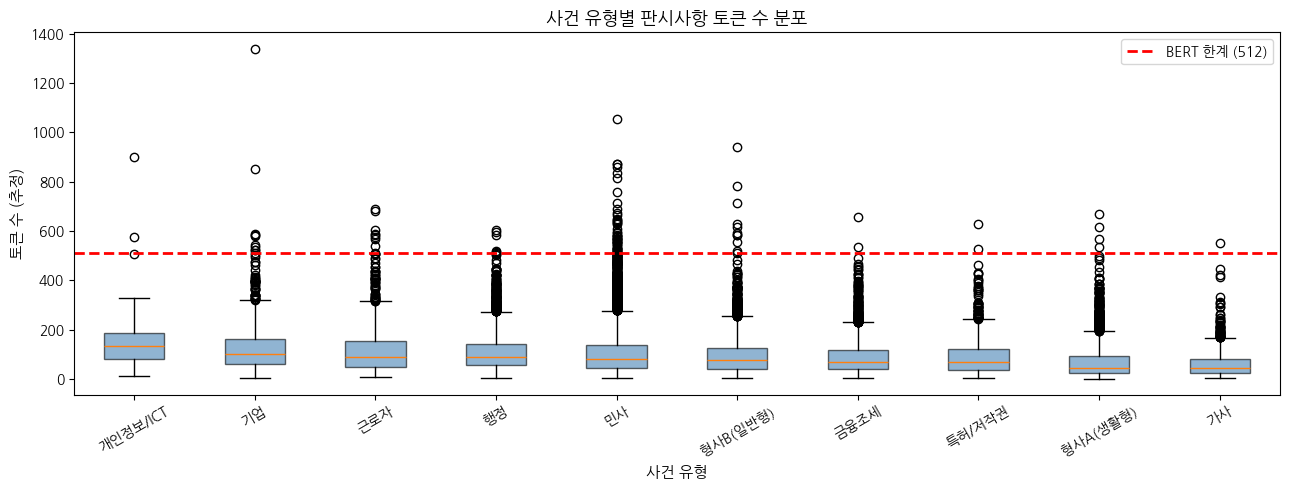

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))

order = train.groupby('class_name')['jdgmn_token'].median().sort_values(ascending=False).index
data_to_plot = [train[train['class_name']==c]['jdgmn_token'].values for c in order]

bp = ax.boxplot(data_to_plot, labels=order, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)

ax.axhline(512, color='red', linestyle='--', linewidth=2, label='BERT 한계 (512)')
ax.set_title('사건 유형별 판시사항 토큰 수 분포', fontsize=13)
ax.set_xlabel('사건 유형', fontsize=11)
ax.set_ylabel('토큰 수 (추정)', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig('length_by_class.png', dpi=150)
plt.show()

## 5. 카테고리 간 유사도 히트맵

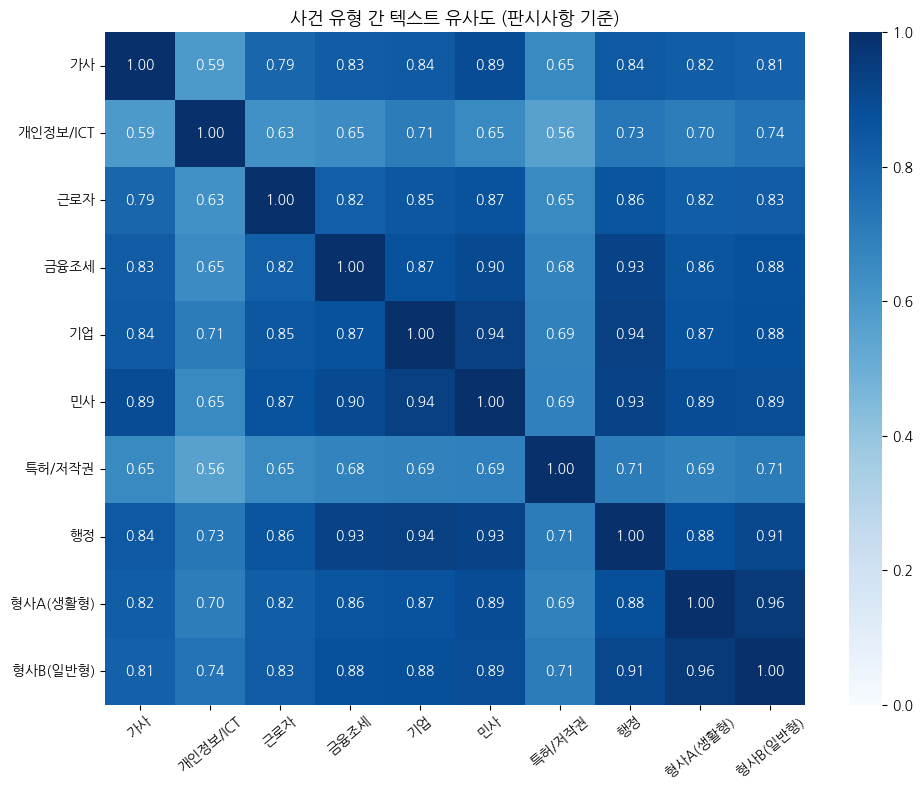

값이 1에 가까울수록 두 유형의 텍스트가 비슷하다는 의미예요.


In [18]:
# 각 카테고리별 텍스트를 합쳐서 TF-IDF 벡터로 변환
classes = sorted(train['class_name'].unique())
class_texts = [' '.join(train[train['class_name']==c]['jdgmn'].fillna('').tolist()) for c in classes]

tfidf = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf.fit_transform(class_texts)
similarity = cosine_similarity(tfidf_matrix)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.eye(len(classes), dtype=bool)  # 대각선 제외

sns.heatmap(similarity,
            xticklabels=classes,
            yticklabels=classes,
            annot=True, fmt='.2f',
            cmap='Blues',
            vmin=0, vmax=1,
            ax=ax)

ax.set_title('사건 유형 간 텍스트 유사도 (판시사항 기준)', fontsize=13)
ax.tick_params(axis='x', rotation=40)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('category_similarity_heatmap.png', dpi=150)
plt.show()

print('값이 1에 가까울수록 두 유형의 텍스트가 비슷하다는 의미예요.')

## 6. 클래스별 대표 명사 시각화


In [21]:
from konlpy.tag import Okt
from collections import Counter

okt = Okt()

# 불용어 (의미 없는 단어 제거)
stopwords = {'경우', '것', '이', '그', '및', '등', '수', '위', '의', '가', '을', '를',
             '에', '는', '이다', '있다', '하다', '되다', '않다', '없다', '때', '법',
             '원심', '피고인', '원고', '피고', '사건', '판결', '법원', '대법원'}

# 클래스별 상위 명사 추출 (샘플 200건씩만 사용 - 속도 때문에)
classes = sorted(train['class_name'].unique())
class_keywords = {}

print('명사 추출 중... (시간이 조금 걸려요)')
for cls in classes:
    texts = train[train['class_name'] == cls]['jdgmn'].fillna('').sample(
        min(200, len(train[train['class_name'] == cls])), random_state=42
    ).tolist()
    combined = ' '.join(texts)
    nouns = okt.nouns(combined)
    # 2글자 이상, 불용어 제외
    nouns = [n for n in nouns if len(n) >= 2 and n not in stopwords]
    class_keywords[cls] = Counter(nouns).most_common(10)
    print(f'  {cls} 완료')

print('완료!')

명사 추출 중... (시간이 조금 걸려요)
  가사 완료
  개인정보/ICT 완료
  근로자 완료
  금융조세 완료
  기업 완료
  민사 완료
  특허/저작권 완료
  행정 완료
  형사A(생활형) 완료
  형사B(일반형) 완료
완료!


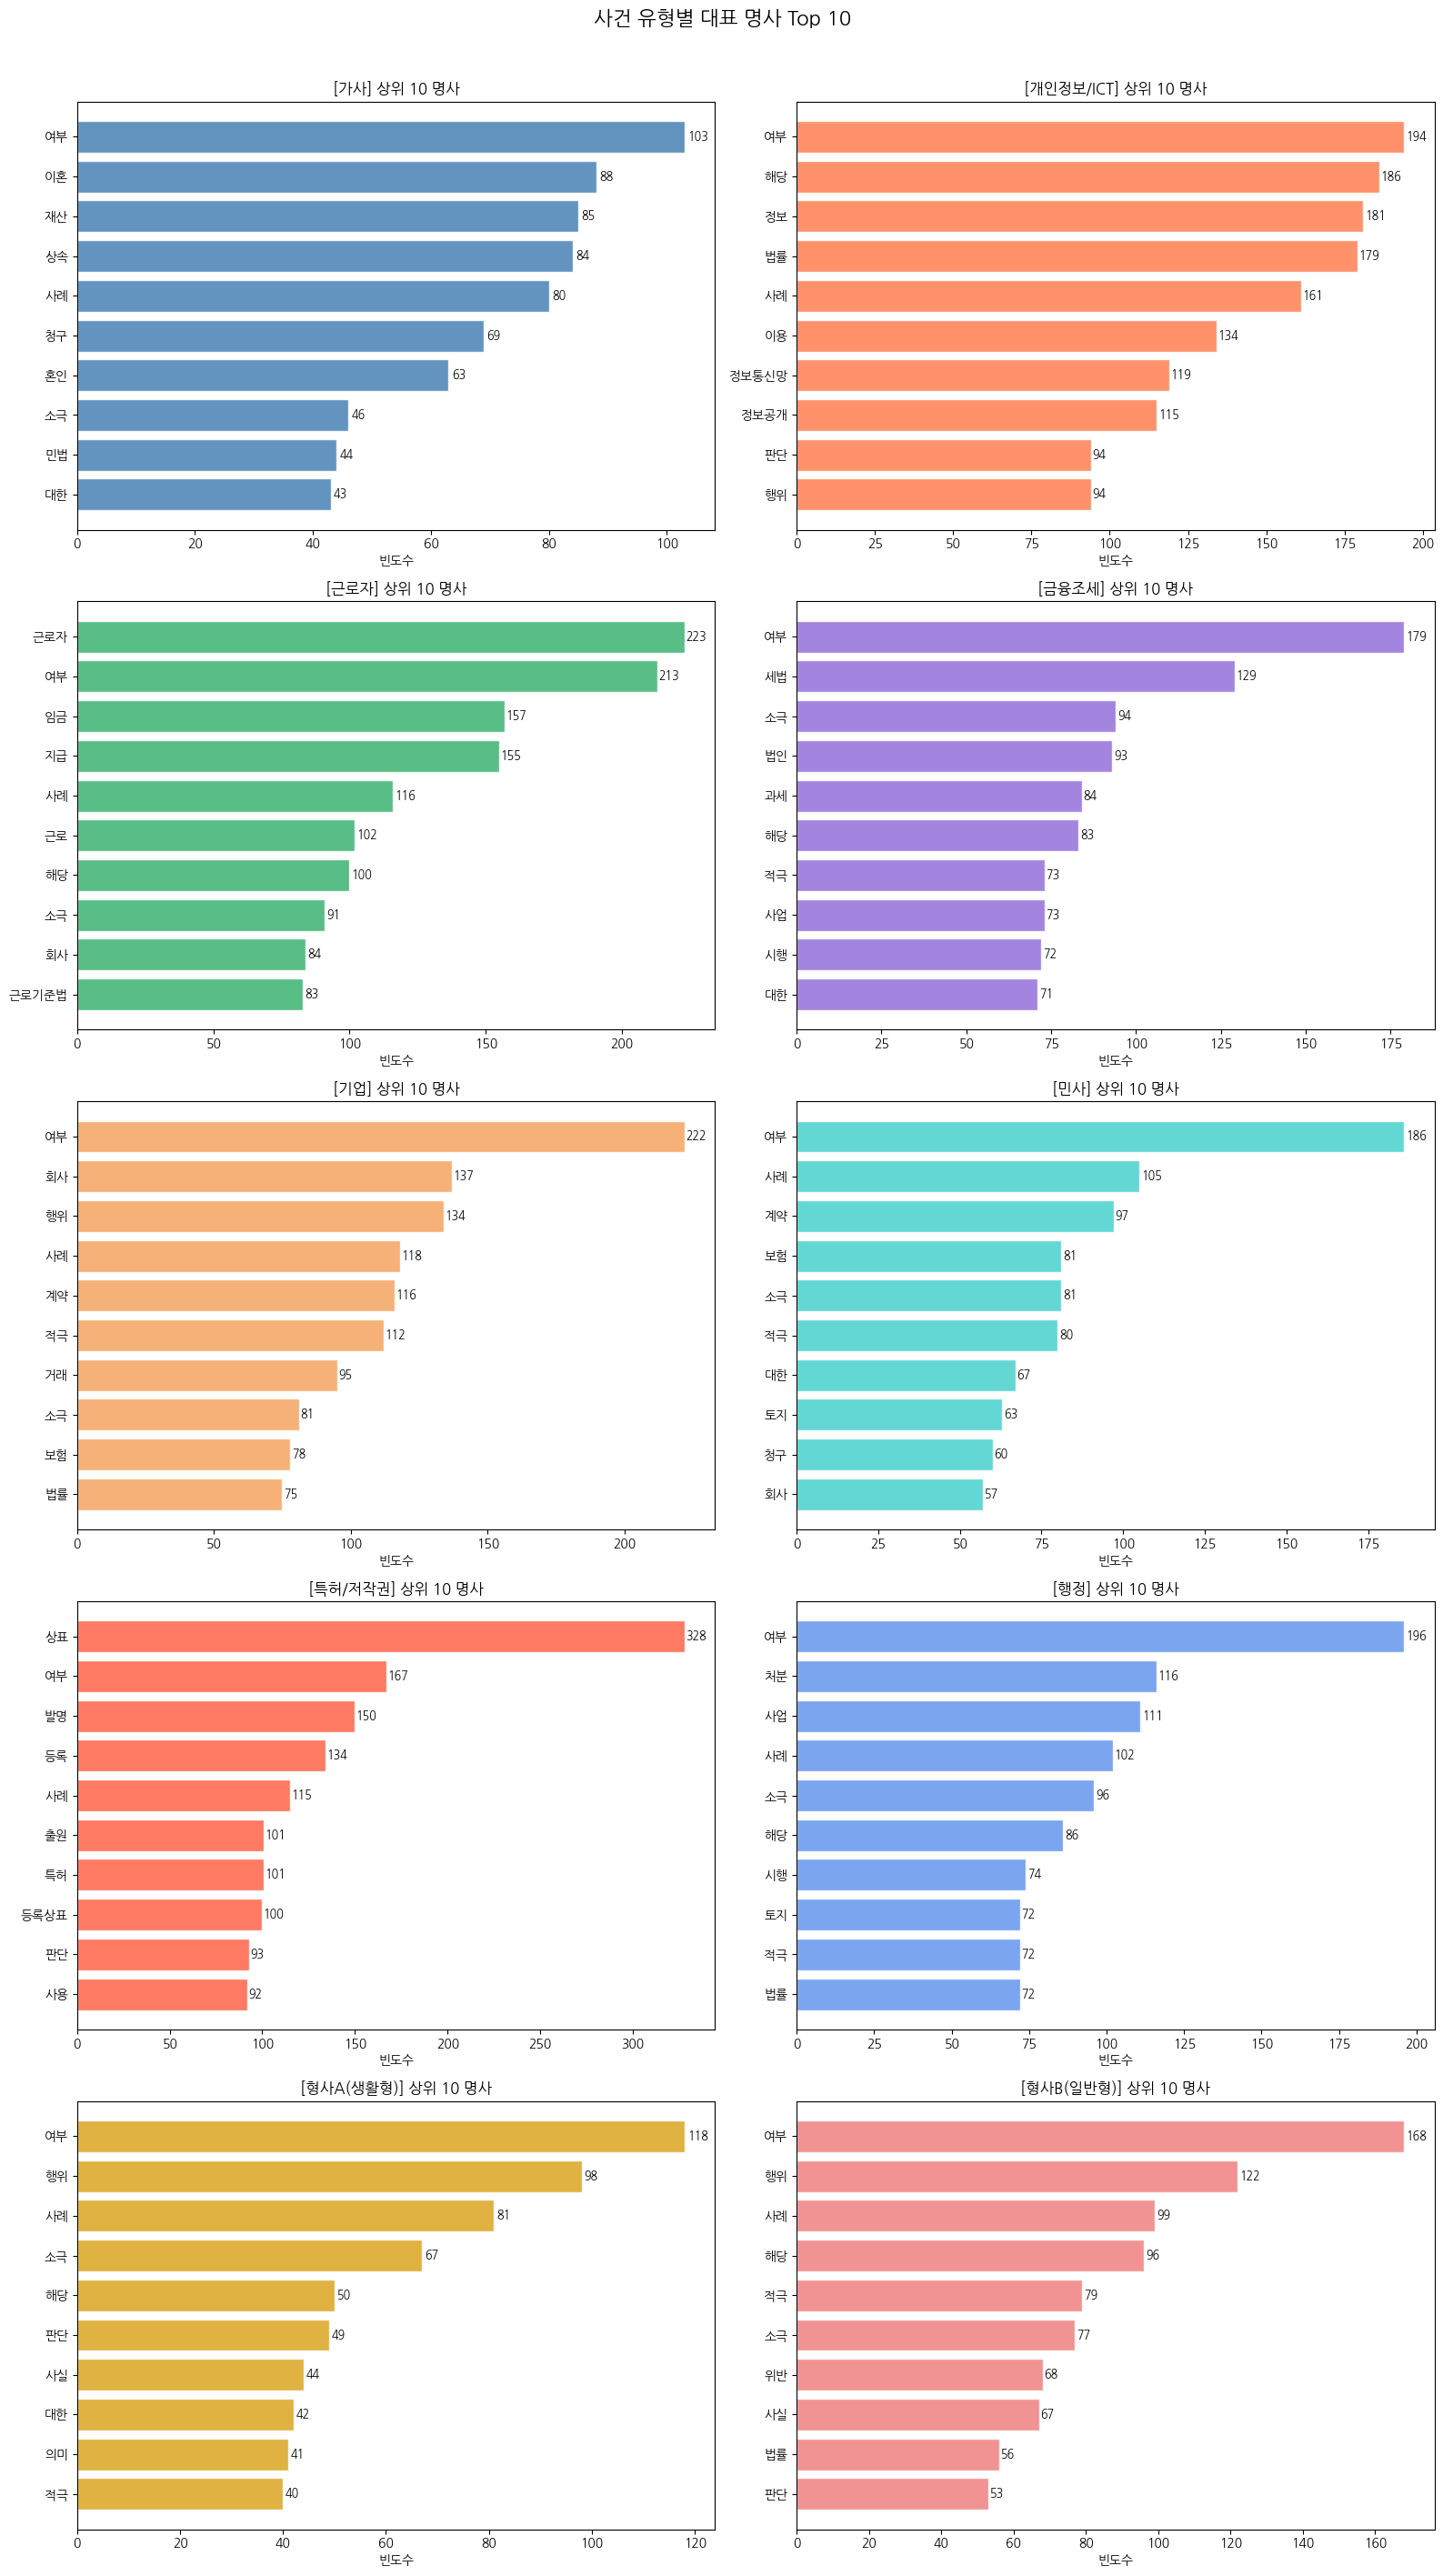

In [22]:
# 클래스별 대표 명사 막대그래프
fig, axes = plt.subplots(5, 2, figsize=(16, 28))
axes = axes.flatten()

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'sandybrown',
          'mediumturquoise', 'tomato', 'cornflowerblue', 'goldenrod', 'lightcoral']

for idx, (cls, color) in enumerate(zip(classes, colors)):
    words  = [w for w, c in class_keywords[cls]]
    counts = [c for w, c in class_keywords[cls]]

    bars = axes[idx].barh(words[::-1], counts[::-1], color=color, edgecolor='white', alpha=0.85)
    axes[idx].set_title(f'[{cls}] 상위 10 명사', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('빈도수', fontsize=10)

    for bar, cnt in zip(bars, counts[::-1]):
        axes[idx].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                       str(cnt), va='center', fontsize=9)

plt.suptitle('사건 유형별 대표 명사 Top 10', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('class_keywords.png', dpi=150, bbox_inches='tight')
plt.show()





## 7. 결측치 확인

In [19]:
print('=== 학습 데이터 결측치 ===')
print(train[['jdgmn','summ_pass']].isnull().sum())
print(f'\n판시사항 빈 문자열: {(train["jdgmn"].fillna("").str.strip()=="").sum()}건')
print(f'요약문 빈 문자열: {(train["summ_pass"].fillna("").str.strip()=="").sum()}건')

=== 학습 데이터 결측치 ===
jdgmn        0
summ_pass    0
dtype: int64

판시사항 빈 문자열: 0건
요약문 빈 문자열: 0건
